<a href="{{ colab_base_laboratorios }}/Laboratorio_02_pandas_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Lab 2: Estadística Descriptiva Básica 2

## Series de tiempo

El siguiente [dataset](https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv) contiene información del precio del eur/usd  desde el 05/07/2022/ hasta el 12/05/2023 con periodicidad de una hora. El data frame contiene el precio de apertura, cierrre, valor más bajo cotizado, valor más alto cotizado, volumen, spread etc. Para este dataset, realizar lo siguiente:


1. Leer el dataset desde el github.
2. Definir como indice la columna time.
3. Obtenga información del data frame.

4. Determine si hay null, nan en el data frame.

5. Emplea la notacion Pascal Case y trabaja solo con la columa del precio de cierre del eur/usd.  

6. Ahora vamos a determinar cual es la mejor distribución estadística que se ajusta a la diferencia del precio de cierre cada hora, para ello realizamos lo siguiente:
- Determine la diferencia de precio entre horas, agregue una nueva columna llamada DiffPrice, en este punto tu dataframe debe tener solo dos columnas Close, DiffPrice y el indice debe ser el tiempo.
- Para la nueva columna construya un histograma de los datos.
- Determine la mejor distribucion estadística que se ajusta al histograma anterior, para ello puede emplear lo siguente:


https://pypi.org/project/fitter/

```python


from fitter import Fitter, get_common_distributions, get_distributions

f = Fitter(data,
           distributions=['gamma',
                          'lognorm',
                          "beta",
                          "burr",
                          "norm"])
f.fit()
f.summary()
#Indentificamos la mejor distribucion con el error cuadratico medio
f.get_best(method = 'sumsquare_error')
#Indentificamos parametros de la distrubicion beta
f.fitted_param["beta"]

```

Con el metodo get_distributions(), podemos ver todas las distribuciones estadisticas de la libreria. Ajusta a la mejor.  Puede consultar [esta](https://medium.com/the-researchers-guide/finding-the-best-distribution-that-fits-your-data-using-pythons-fitter-library-319a5a0972e9)  página si desea ver un ejemplo.


7. Para el data frame, seleccionemos solo los datos del 2023.

8. El comando groupby permite agrupar los datos con la periodicidad deseada: 1 dias, 2 dias, 1 mes etc. Determina el promedio con una periodicidad de 15 dias, con periodidicidad de 1 semana, y una periodicidad de 1 mes

```python
  df.groupby(pd.Grouper(key='time', freq='15D')).mean()
```

9. Para los datos asociados a los meses de 2023, construya un histograma para cada mes.  Para ello puedo emplear el metodo groupby. Notetese que si no  realiza una operación después de aplicar el metodo grouby, podrias iterar sobre dicho objeto, por ejemplo:

```python
q=df.groupby(pd.Grouper(key='time', freq='15D'))

for name, group in q:
  print(name, group)
```


## Análisis de datos con pandas.

Para el siguiente [dataset](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29) realizar lo siguiente:


1. Leer los datos desde una página web.

2. Renombrar las columnas en formato PascalCase.

3. Utilizar los métodos `head()`, `tail()`, `describe()` e `info()` para obtener información sobre el `DataFrame`.

4. Contabilizar la cantidad de valores nulos (`null` o `NaN`) en el `DataFrame`.
   Si se encuentran valores nulos, ¿qué estrategia propondrías para reemplazarlos?

5. Identificar los valores únicos en la columna `target` que representan las etiquetas B y M (Benigno y Maligno, respectivamente).
   Utiliza el método `unique()` para mostrar estos valores.

6. Realizar un conteo de los casos etiquetados como B y M utilizando la librería `seaborn` y el método `countplot()`:

```python
import seaborn as sns
sns.countplot?
```

7. Agregar una nueva columna llamada `DiagnosisNumeric` donde se asigna el valor 0 a la etiqueta B (Benigno) y el valor 1 a la etiqueta M (Maligno).


8. Normalizar cada columna respecto a su media y desviación estándar utilizando la fórmula:  
   `(x - mean(x)) / std(x)`

9. Agrupar características similares y calcular su promedio.
   Para las siguientes características:

```python
['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', "SymmetryMean", "FractalDimensionMean"]
```

Usa expresiones regulares para identificar patrones comunes, como `radius1`, `radius2`,`radius3`, etc., y calcular los promedios. Por ejemplo:

```python
re.match(r'^[a-zA-Z_]+', "holamundo12341").group(0)
```

También puedes utilizar el método `startswith()` para buscar estos patrones en los nombres de las columnas.


10. Crear un gráfico donde se muestre el histograma de la columna `RadiusMean` separado por las etiquetas B y M, utilizando colores diferentes (naranja y azul, respectivamente) para cada diagnóstico.

11. Generar gráficos de violín para múltiples características.
   Para las columnas:

   - `RadiusMean`
   - `TextureMean`
   - `PerimeterMean`
   - `AreaMean`
   - `SmoothnessMean`
   - `CompactnessMean`
   - `ConcavityMean`
   - `ConcavePointsMean`
   - `Symmetry3`
   - `FractalDimension3`

   Realiza un gráfico múltiple tipo violín, como en el siguiente ejemplo:

```python
data = pd.melt(df.iloc[:, 0:10], id_vars="Diagnosis", var_name="features", value_name="value")
sns.violinplot(x="features", y="value", hue="Diagnosis", data=data, split=True, inner="quart")
plt.xticks(rotation=45)
```


12.  Determinar y eliminar los valores atípicos (`outliers`) en la columna `RadiusMean`.

Para identificarlos, construye un gráfico tipo `boxplot`:

```python
df.boxplot(column="RadiusMean", by='Diagnosis', sym='k.', figsize=(18,6))
```

Usa el rango intercuartílico (IQR) para definir los outliers. Los valores fuera del rango [Q1 - 1.5 * IQR, Q3 + 1.5 * IQR] se consideran outliers. Ejemplo de cómo eliminar estos valores:

```python
Q1 = df['edad'].quantile(0.25)
Q3 = df['edad'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['edad'] < (Q1 - 1.5 * IQR)) | (df['edad'] > (Q3 + 1.5 * IQR)))]
```

Otra alternativa es utilizar el puntaje Z para detectar `outliers`:

```python
df = df[(np.abs(stats.zscore(df['edad'])) < 3)]
```



13. Encontrar la matrix de correlación, emplear el metodo corr(), dentro de seaborn buscar el metodo heatmap() para realizar un grafico de la matrix de correlación.

14. ¿Que otro tipo de gráficos pueden ser realizados para entender mejor los datos?



##Librerias.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
!pip install fitter

#DataFrame
##Series de tiempo.
1). Apartir del enlace, creamos el dataset y cambiamos la columna time para volverla como indice.

In [ ]:
url = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv"
df = pd.read_csv(url)
df = df.set_index("time")
df

,Unnamed: 0,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
time,,,,,,,,,,,,
2022-07-25 13:00:00,0,1.02427,1.02430,1.02145,1.02345,3927,8,0,1.023860,-0.00046,-0.00082,-0.000640
2022-07-25 14:00:00,1,1.02345,1.02578,1.02288,1.02299,5344,8,0,1.023220,-0.00046,-0.00082,-0.000640
2022-07-25 15:00:00,2,1.02303,1.02476,1.02230,1.02457,5524,8,0,1.023800,0.00158,-0.00042,0.000580
2022-07-25 16:00:00,3,1.02454,1.02548,1.02355,1.02485,5234,8,0,1.024695,0.00028,0.00151,0.000895
2022-07-25 17:00:00,4,1.02485,1.02514,1.02030,1.02181,9031,7,0,1.023330,-0.00304,0.00031,-0.001365
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-05-12 19:00:00,4995,1.08552,1.08569,1.08485,1.08514,2275,8,0,1.085330,-0.00038,-0.00071,-0.000545
2023-05-12 20:00:00,4996,1.08516,1.08567,1.08502,1.08546,1676,8,0,1.085310,0.00032,-0.00036,-0.000020
2023-05-12 21:00:00,4997,1.08546,1.08546,1.08487,1.08531,1828,8,0,1.085385,-0.00015,0.00030,0.000075


3) Información del dataframe.

In [ ]:
informacion_df = df.info()
informacion_df

<class 'pandas.DataFrame'>
Index: 5000 entries, 2022-07-25 13:00:00 to 2023-05-12 23:00:00
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          5000 non-null   int64  
 1   open                5000 non-null   float64
 2   high                5000 non-null   float64
 3   low                 5000 non-null   float64
 4   close               5000 non-null   float64
 5   tick_volume         5000 non-null   int64  
 6   spread              5000 non-null   int64  
 7   real_volume         5000 non-null   int64  
 8   MeanCloseOpen       5000 non-null   float64
 9   Diff_Close          5000 non-null   float64
 10  Diff_Open           5000 non-null   float64
 11  Diff_MeanCloseOpen  5000 non-null   float64
dtypes: float64(8), int64(4)
memory usage: 598.6 KB


4). ¿Hay null, nan en el dataframe?\
Rta//:

In [ ]:
bolsa_valor = list(df.columns)
nan = []

for i in range(len(bolsa_valor)):
  nan.append(df[bolsa_valor[i]].isna().sum())

print(np.int64(nan))

[0 0 0 0 0 0 0 0 0 0 0 0]


Al examinar la información del DataFrame, podemos observar que no existen valores nulos (non-null). Además, mediante el código implementado, verificamos que no hay valores NaN. Por lo tanto, podemos concluir que el DataFrame contiene datos completos y no presenta valores faltantes.

5). Empleando la notación PascalCase, se define una variable para trabajar únicamente con la columna correspondiente al precio de cierre.

In [ ]:
Precio_Del_Cierre = df["MeanCloseOpen"]
Precio_Del_Cierre

time
2022-07-25 13:00:00    1.023860
2022-07-25 14:00:00    1.023220
2022-07-25 15:00:00    1.023800
2022-07-25 16:00:00    1.024695
2022-07-25 17:00:00    1.023330
                         ...   
2023-05-12 19:00:00    1.085330
2023-05-12 20:00:00    1.085310
2023-05-12 21:00:00    1.085385
2023-05-12 22:00:00    1.085245
2023-05-12 23:00:00    1.085075
Name: MeanCloseOpen, Length: 5000, dtype: float64

6). Para encontrar la distribución estadística que mejor se ajusta a los datos, se crea una nueva columna denominada DiffPrice, que contiene la diferencia entre los precios de cierre correspondientes a horas consecutivas. De esta manera, se obtiene un nuevo DataFrame compuesto por dos columnas: close, que contiene el precio de cierre, y DiffPrice, que representa la variación del precio de cierre entre horas consecutivas.

In [ ]:
df1 =df[["close"]].copy()
df1["DiffPrice"]  = df1["close"].diff()
diffprice = df1["DiffPrice"]
df1

,close,DiffPrice
time,,
2022-07-25 13:00:00,1.02345,NaN
2022-07-25 14:00:00,1.02299,-0.00046
2022-07-25 15:00:00,1.02457,0.00158
2022-07-25 16:00:00,1.02485,0.00028
2022-07-25 17:00:00,1.02181,-0.00304
...,...,...
2023-05-12 19:00:00,1.08514,-0.00038
2023-05-12 20:00:00,1.08546,0.00032
2023-05-12 21:00:00,1.08531,-0.00015


Para la nueva columna vamos a generar un histograma.

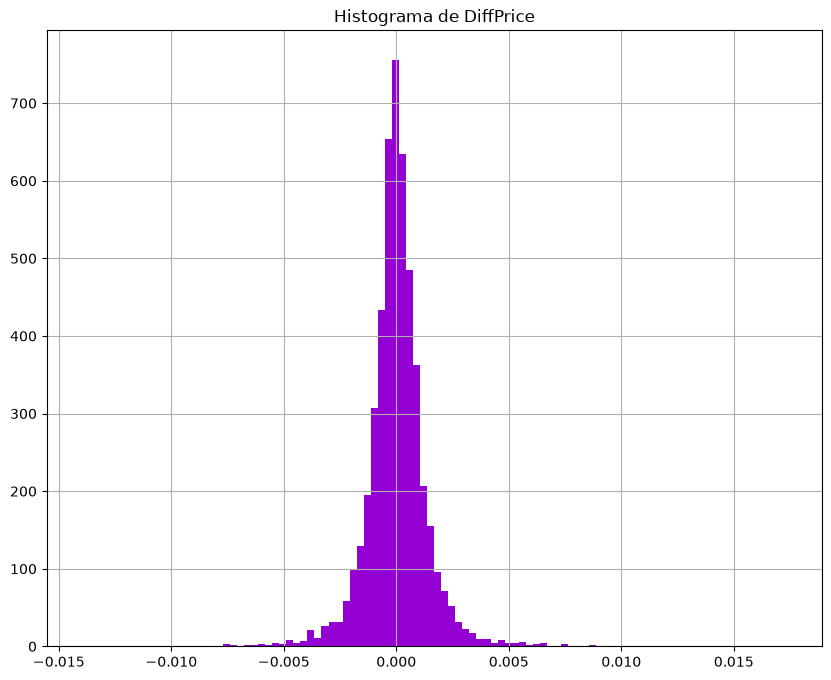

In [ ]:
plt.figure(figsize = (10 , 8))
plt.title("Histograma de DiffPrice")
plt.hist(diffprice, bins = 100 , color = "darkviolet")
plt.grid(True)
plt.show()

definiendo la mejor distribución estadística utilizamos la guia dada.

La mejor distribución es: lognorm
(np.float64(14613.868594375072), np.float64(27361.660606098114), np.float64(-0.2096488866774875), np.float64(0.6022115067129248))


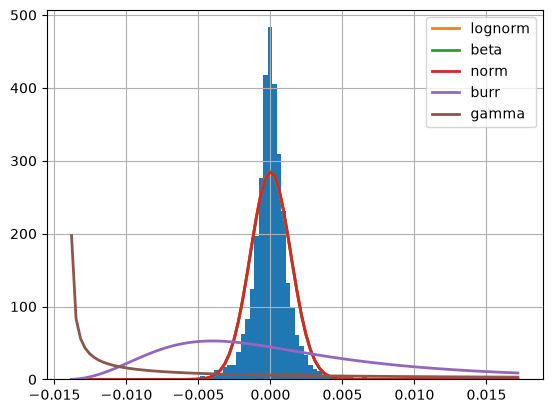

In [ ]:
from fitter import Fitter, get_common_distributions, get_distributions

f = Fitter(diffprice.dropna(),
           distributions=['gamma',
                          'lognorm',
                          "beta",
                          "burr",
                          "norm"])
f.fit()
f.summary()

best_dist_info = f.get_best(method = 'sumsquare_error')
print(f"La mejor distribución es: {list(best_dist_info.keys())[0]}")

if "beta" in f.fitted_param:
    print(f.fitted_param["beta"])
else:
    print("La distribución 'beta' no pudo ser ajustada a los datos o no es la mejor.")

    plt.show()

7) Creamos un dataframe con solo los datos del 2023.

In [ ]:
df.index = pd.to_datetime(df.index)
datos_2023 = df.loc['2023']
datos_2023

,Unnamed: 0,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
time,,,,,,,,,,,,
2023-01-02 00:00:00,2722,1.06998,1.07061,1.06795,1.06796,98,57,0,1.068970,-0.00200,-0.00063,-0.001315
2023-01-02 01:00:00,2723,1.06847,1.06965,1.06847,1.06965,91,183,0,1.069060,0.00169,-0.00151,0.000090
2023-01-02 02:00:00,2724,1.06965,1.07060,1.06904,1.07058,325,11,0,1.070115,0.00093,0.00118,0.001055
2023-01-02 03:00:00,2725,1.07058,1.07075,1.06837,1.06896,271,26,0,1.069770,-0.00162,0.00093,-0.000345
2023-01-02 04:00:00,2726,1.06895,1.06896,1.06799,1.06880,137,78,0,1.068875,-0.00016,-0.00163,-0.000895
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-05-12 19:00:00,4995,1.08552,1.08569,1.08485,1.08514,2275,8,0,1.085330,-0.00038,-0.00071,-0.000545
2023-05-12 20:00:00,4996,1.08516,1.08567,1.08502,1.08546,1676,8,0,1.085310,0.00032,-0.00036,-0.000020
2023-05-12 21:00:00,4997,1.08546,1.08546,1.08487,1.08531,1828,8,0,1.085385,-0.00015,0.00030,0.000075


8): El comando groupby nos permite determinar la periodicidad deseada, en nuestro caso es de 15 dias, 1 semana y 1 mes.

In [ ]:
periodo_15_d = df.groupby(pd.Grouper(level='time', freq='15D')).mean()
periodo_1_sem = df.groupby(pd.Grouper(level='time', freq='1W')).mean()
periodo_1_mes = df.groupby(pd.Grouper(level='time', freq='1ME')).mean()

###Periodicidad 15 días

In [ ]:
periodo_15_d

,Unnamed: 0,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
time,,,,,,,,,,,,
2022-07-25,125.0,1.019610,1.020562,1.018630,1.019602,3789.107570,9.119522,0.0,1.019606,-0.000019,-0.000023,-0.000021
2022-08-09,382.5,1.016238,1.016969,1.015419,1.016159,2972.234848,9.208333,0.0,1.016199,-0.000086,-0.000085,-0.000085
2022-08-24,646.5,0.996908,0.997953,0.995986,0.996934,3684.606061,8.992424,0.0,0.996921,0.000015,0.000015,0.000015
2022-09-08,910.5,0.999835,1.000790,0.998795,0.999753,4266.166667,8.893939,0.0,0.999794,-0.000065,-0.000064,-0.000065
2022-09-23,1174.5,0.976705,0.978025,0.975436,0.976675,5837.492424,9.185606,0.0,0.976690,-0.000035,-0.000038,-0.000037
2022-10-08,1426.5,0.976099,0.977243,0.975039,0.976156,5239.412500,8.900000,0.0,0.976128,0.000049,0.000051,0.000050
2022-10-23,1666.0,0.990759,0.991866,0.989720,0.990803,4990.966527,8.937238,0.0,0.990781,0.000042,0.000042,0.000042
2022-11-07,1917.5,1.021983,1.023232,1.020866,1.022115,5112.587121,8.856061,0.0,1.022049,0.000107,0.000107,0.000107
2022-11-22,2181.5,1.041266,1.042351,1.040181,1.041364,4472.219697,8.795455,0.0,1.041315,0.000086,0.000086,0.000086


###Periodicidad 1 semana

In [ ]:
periodo_1_sem

,Unnamed: 0,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
time,,,,,,,,,,,,
2022-07-31,53.0,1.018310,1.019409,1.017178,1.018298,3859.401869,8.850467,0.0,1.018304,-0.000013,-2.738318e-05,-2.009346e-05
2022-08-07,166.5,1.020912,1.021790,1.020035,1.020890,3940.675000,9.408333,0.0,1.020901,-0.000038,-3.658333e-05,-3.725000e-05
2022-08-14,286.5,1.025224,1.025973,1.024472,1.025295,2894.391667,9.025000,0.0,1.025260,0.000065,6.891667e-05,6.683333e-05
2022-08-21,406.5,1.015349,1.016014,1.014518,1.015174,2837.108333,9.166667,0.0,1.015262,-0.000181,-1.834167e-04,-1.824167e-04
2022-08-28,526.5,0.997254,0.998184,0.996330,0.997196,3317.033333,9.225000,0.0,0.997225,-0.000066,-6.241667e-05,-6.395833e-05
2022-09-04,646.5,0.999486,1.000554,0.998540,0.999479,3823.725000,8.950000,0.0,0.999482,-0.000009,-1.133333e-05,-1.033333e-05
2022-09-11,766.5,0.996214,0.997269,0.995311,0.996315,4025.625000,8.975000,0.0,0.996264,0.000079,7.808333e-05,7.870833e-05
2022-09-18,886.5,1.003422,1.004346,1.002358,1.003355,4106.916667,8.975000,0.0,1.003388,-0.000026,-2.750000e-05,-2.691667e-05
2022-09-25,1006.5,0.990885,0.991834,0.989767,0.990617,4541.283333,8.866667,0.0,0.990751,-0.000272,-2.680000e-04,-2.700000e-04


###Periodicidad 1 mes

In [ ]:
periodo_1_mes

,Unnamed: 0,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
time,,,,,,,,,,,,
2022-07-31,53.0,1.018310,1.019409,1.017178,1.018298,3859.401869,8.850467,0.0,1.018304,-0.000013,-0.000027,-0.000020
2022-08-31,382.5,1.012754,1.013610,1.011906,1.012731,3319.713768,9.173913,0.0,1.012742,-0.000031,-0.000031,-0.000031
2022-09-30,922.5,0.990412,0.991527,0.989313,0.990365,4722.812500,8.984848,0.0,0.990388,-0.000048,-0.000047,-0.000048
2022-10-31,1438.5,0.983676,0.984777,0.982582,0.983698,5206.746032,9.011905,0.0,0.983687,0.000016,0.000015,0.000016
2022-11-30,1954.0,1.019757,1.020931,1.018684,1.019872,4796.717268,8.844402,0.0,1.019815,0.000099,0.000101,0.000100
2022-12-31,2469.5,1.058424,1.059390,1.057494,1.058478,3839.261905,8.773810,0.0,1.058451,0.000059,0.000059,0.000059
2023-01-31,2985.5,1.077433,1.078325,1.076588,1.077463,3347.763258,9.577652,0.0,1.077448,0.000031,0.000031,0.000031
2023-02-28,3489.5,1.071221,1.071972,1.070433,1.071167,3029.912500,8.825000,0.0,1.071194,-0.000060,-0.000062,-0.000061
2023-03-31,4004.5,1.070837,1.071657,1.070032,1.070874,3282.461818,8.901818,0.0,1.070855,0.000049,0.000049,0.000049


9). Histograma para cada mes apartir del dataframe 2023

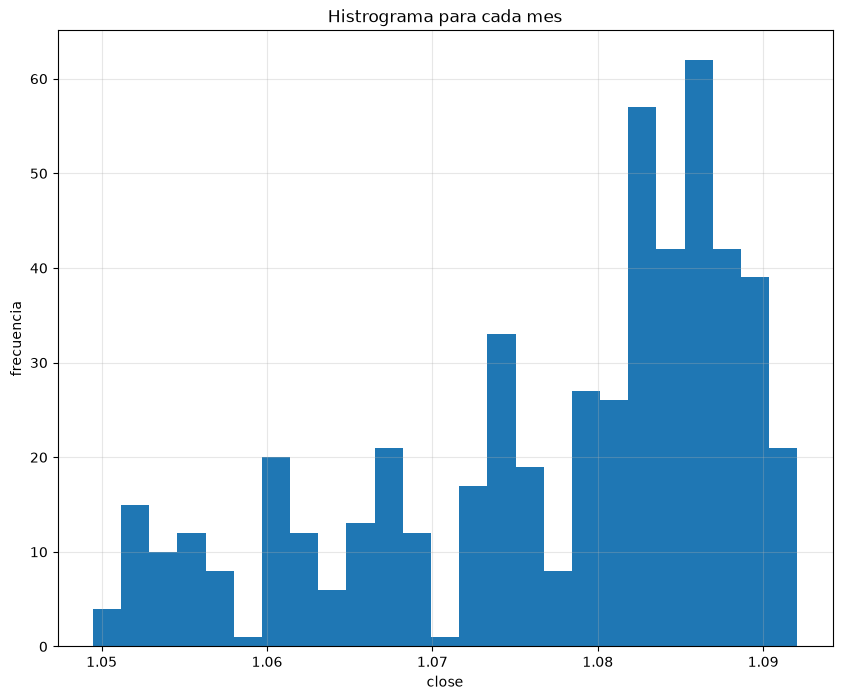

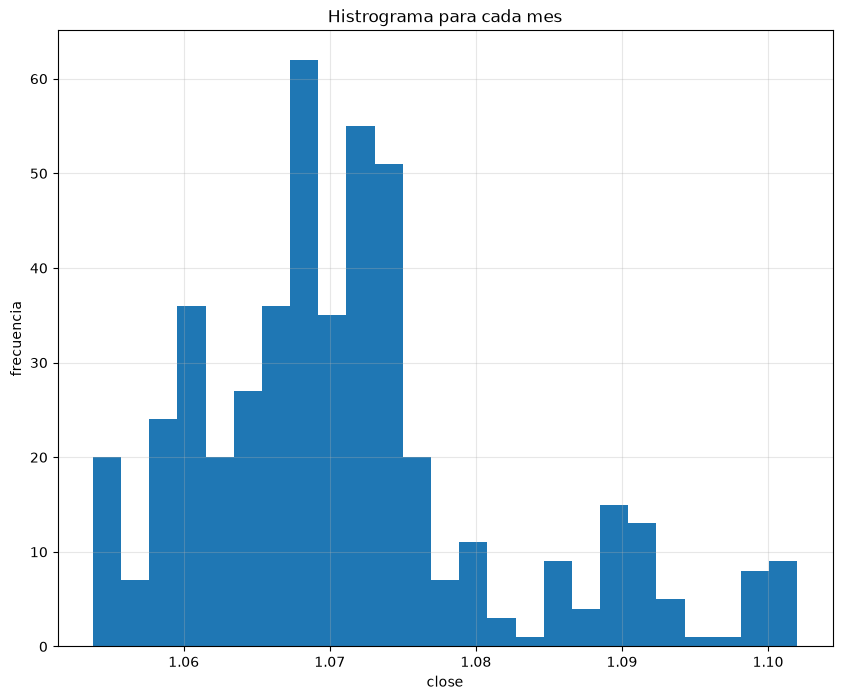

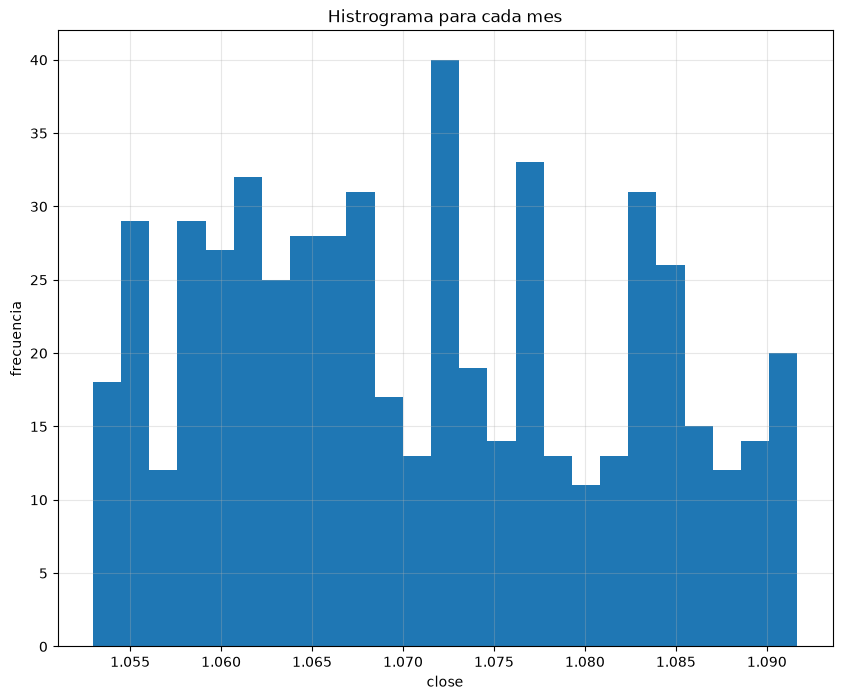

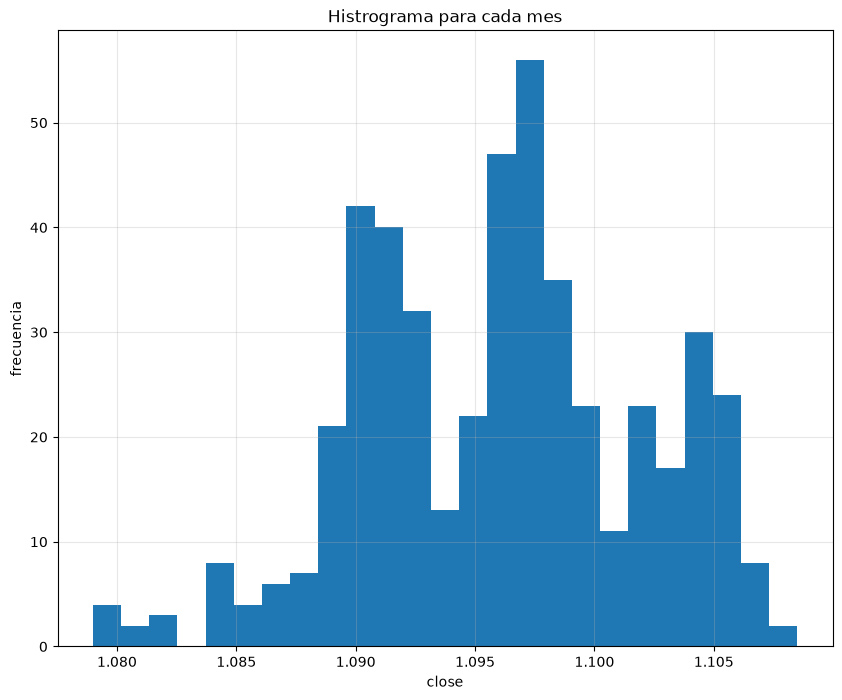

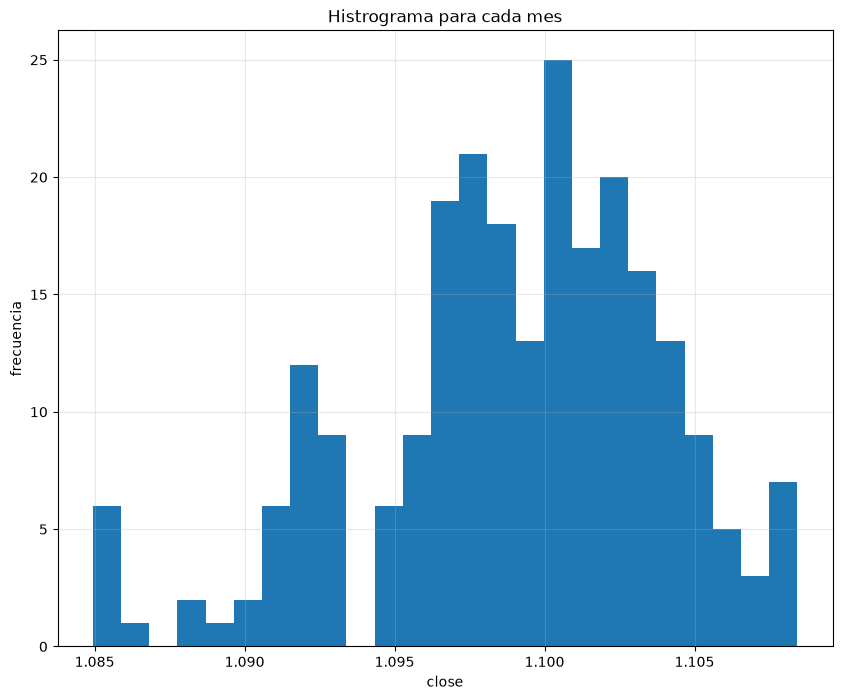

In [ ]:
meses = datos_2023.groupby(pd.Grouper(level = "time" , freq = "1ME"))
for name , group in meses:
    plt.figure(figsize=(10,8))
    plt.hist(group["close"] , bins = 25)
    plt.title("Histrograma para cada mes")
    plt.xlabel("close")
    plt.ylabel("frecuencia")
    plt.grid(alpha = 0.3)
    plt.show()


##Analisis de datos con pandas.
1) Subiendo directamente el dataframe tenemos que.

In [ ]:
from google.colab import files

archivo = files.upload()

Saving breast+cancer+wisconsin+diagnostic.zip to breast+cancer+wisconsin+diagnostic.zip


In [ ]:
import zipfile

with zipfile.ZipFile("breast+cancer+wisconsin+diagnostic.zip", "r") as zip_ref:
    zip_ref.extractall("breast_cancer")

import pandas as pd

dg = pd.read_csv("breast_cancer/wdbc.data", header=None)

dg.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


2). Renombrando las columnas para este dataframe en formato PascalCase.

In [ ]:
dg.columns = ["ID", "Diagnostico", "RadioMedia", "TexturaMedia", "PerimetroMedia", "AreaMedia", "SuavidadMedia", "CompacidadMedia", "ConcavidadMedia","PuntosConcavosMedia", "SimetriaMedia","DimensionFractalMedia", "RadioSe", "TexturaSe", "PerimetroSe", "AreaSe", "SuavidadSe", "CompacidadSe" "ConcavidadSe", "PuntosConcavosSe", "SimetriaSe", "DimensionFractalSe", "RadioPeor","TexturaPeor", "PerimetroPeor","AreaPeor","SuavidadPeor" "CompacidadPeor","ConcavidadPeor", "PuntosConcavosPeor", "SimetriaPeor","DimensionFractalPeor"]
dg

,ID,Diagnostico,RadioMedia,TexturaMedia,PerimetroMedia,AreaMedia,SuavidadMedia,CompacidadMedia,ConcavidadMedia,PuntosConcavosMedia,...,RadioPeor,TexturaPeor,PerimetroPeor,AreaPeor,SuavidadPeor,CompacidadPeor,ConcavidadPeor,PuntosConcavosPeor,SimetriaPeor,DimensionFractalPeor
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


3). Obteniendo la información del dataframe mediante los métodos: head() , tail(), describe(), e info().

In [ ]:
dg.head()

,ID,Diagnostico,RadioMedia,TexturaMedia,PerimetroMedia,AreaMedia,SuavidadMedia,CompacidadMedia,ConcavidadMedia,PuntosConcavosMedia,...,RadioPeor,TexturaPeor,PerimetroPeor,AreaPeor,SuavidadPeor,CompacidadPeor,ConcavidadPeor,PuntosConcavosPeor,SimetriaPeor,DimensionFractalPeor
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
dg.tail()

,ID,Diagnostico,RadioMedia,TexturaMedia,PerimetroMedia,AreaMedia,SuavidadMedia,CompacidadMedia,ConcavidadMedia,PuntosConcavosMedia,...,RadioPeor,TexturaPeor,PerimetroPeor,AreaPeor,SuavidadPeor,CompacidadPeor,ConcavidadPeor,PuntosConcavosPeor,SimetriaPeor,DimensionFractalPeor
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [ ]:
dg.describe()

,ID,RadioMedia,TexturaMedia,PerimetroMedia,AreaMedia,SuavidadMedia,CompacidadMedia,ConcavidadMedia,PuntosConcavosMedia,SimetriaMedia,...,RadioPeor,TexturaPeor,PerimetroPeor,AreaPeor,SuavidadPeor,CompacidadPeor,ConcavidadPeor,PuntosConcavosPeor,SimetriaPeor,DimensionFractalPeor
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [ ]:
dg.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     569 non-null    int64  
 1   Diagnostico            569 non-null    str    
 2   RadioMedia             569 non-null    float64
 3   TexturaMedia           569 non-null    float64
 4   PerimetroMedia         569 non-null    float64
 5   AreaMedia              569 non-null    float64
 6   SuavidadMedia          569 non-null    float64
 7   CompacidadMedia        569 non-null    float64
 8   ConcavidadMedia        569 non-null    float64
 9   PuntosConcavosMedia    569 non-null    float64
 10  SimetriaMedia          569 non-null    float64
 11  DimensionFractalMedia  569 non-null    float64
 12  RadioSe                569 non-null    float64
 13  TexturaSe              569 non-null    float64
 14  PerimetroSe            569 non-null    float64
 15  AreaSe           

4). Dada la información del DataFrame, podemos observar que contamos con 569 valores non-null. Sin embargo, mediante un código adicional verificamos si existe algún valor NaN en cada una de las columnas.

In [ ]:
cancer = list(dg.columns)
nan = []

for i in range(len(cancer)):
  nan.append(dg[cancer[i]].isna().sum())

print(np.int64(nan), len(nan))

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] 32


Como resultado, se comprobó que no hay ningún valor NaN en el DataFrame, por lo que podemos concluir que no existen datos faltantes.\
5). Utilizando el método unique(), se determinan los valores únicos presentes en la columna diagnostico. Esto permite identificar las diferentes categorías que contiene dicha columna.

In [ ]:
valores_unicos = dg["Diagnostico"].unique()
valores_unicos

<ArrowStringArray>
['M', 'B']
Length: 2, dtype: str

Efectivamente tenemos dos etiquetas, B y M, de tipo string.\
6). Realizando el conteo para las etiquetas B y M.

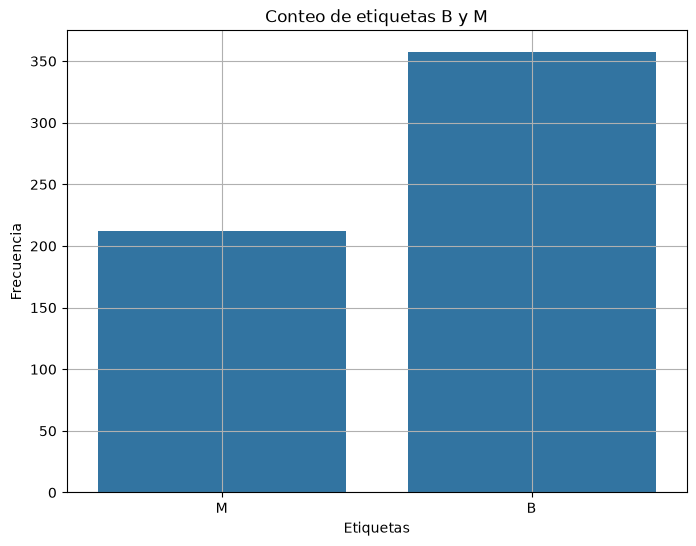

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x = "Diagnostico", data = dg)
plt.title("Conteo de etiquetas B y M")
plt.xlabel("Etiquetas")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

In [ ]:
conteo = dg["Diagnostico"].value_counts()
conteo

Diagnostico
B    357
M    212
Name: count, dtype: int64

Podemos ver que B tiene 357 y M 212 conteos.\
7.) Agregando una nueva columna donde para asignarle 0 y 1 para las etiquetas, es decir:

In [ ]:
dg["DiagnosticNumber"] = dg["Diagnostico"].map({"B": 0, "M": 1})
dg1 = dg[["Diagnostico" , "DiagnosticNumber"]]
dg1.head()

,Diagnostico,DiagnosticNumber
0,M,1
1,M,1
2,M,1
3,M,1
4,M,1


8). Normalizando cada columna mediante la ecuación: $$
\frac{x-\operatorname{mean}(x)}{\operatorname{std}(x)}
$$

In [ ]:
normalizar = []

columnas_numericas = dg.select_dtypes(include=np.number).columns.drop('ID', errors='ignore')

for col_name in columnas_numericas:
  normalizar.append((dg[col_name] - np.mean(dg[col_name])) / dg[col_name].std())

normalizar = pd.DataFrame(normalizar).T
normalizar

,RadioMedia,TexturaMedia,PerimetroMedia,AreaMedia,SuavidadMedia,CompacidadMedia,ConcavidadMedia,PuntosConcavosMedia,SimetriaMedia,DimensionFractalMedia,...,TexturaPeor,PerimetroPeor,AreaPeor,SuavidadPeor,CompacidadPeor,ConcavidadPeor,PuntosConcavosPeor,SimetriaPeor,DimensionFractalPeor,DiagnosticNumber
0,1.096100,-2.071512,1.268817,0.983510,1.567087,3.280628,2.650542,2.530249,2.215566,2.253764,...,-1.358098,2.301575,1.999478,1.306537,2.614365,2.107672,2.294058,2.748204,1.935312,1.296535
1,1.828212,-0.353322,1.684473,1.907030,-0.826235,-0.486643,-0.023825,0.547662,0.001391,-0.867889,...,-0.368879,1.533776,1.888827,-0.375282,-0.430066,-0.146620,1.086129,-0.243675,0.280943,1.296535
2,1.578499,0.455786,1.565126,1.557513,0.941382,1.052000,1.362280,2.035440,0.938859,-0.397658,...,-0.023953,1.346291,1.455004,0.526944,1.081980,0.854222,1.953282,1.151242,0.201214,1.296535
3,-0.768233,0.253509,-0.592166,-0.763792,3.280667,3.399917,1.914213,1.450431,2.864862,4.906602,...,0.133866,-0.249720,-0.549538,3.391291,3.889975,1.987839,2.173873,6.040726,4.930672,1.296535
4,1.748758,-1.150804,1.775011,1.824624,0.280125,0.538866,1.369806,1.427237,-0.009552,-0.561956,...,-1.465481,1.337363,1.219651,0.220362,-0.313119,0.612640,0.728618,-0.867590,-0.396751,1.296535
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2.109139,0.720838,2.058974,2.341795,1.040926,0.218868,1.945573,2.318924,-0.312314,-0.930209,...,0.117596,1.751022,2.013529,0.378033,-0.273077,0.663928,1.627719,-1.358963,-0.708467,1.296535
565,1.703356,2.083301,1.614511,1.722326,0.102368,-0.017817,0.692434,1.262558,-0.217473,-1.057681,...,2.045599,1.420690,1.493644,-0.690623,-0.394473,0.236365,0.733182,-0.531387,-0.973122,1.296535
566,0.701667,2.043775,0.672084,0.577445,-0.839745,-0.038646,0.046547,0.105684,-0.808406,-0.894800,...,1.373645,0.578492,0.427529,-0.808876,0.350427,0.326479,0.413705,-1.103578,-0.318129,1.296535
567,1.836725,2.334403,1.980781,1.733693,1.524426,3.269267,3.294046,2.656528,2.135315,1.042778,...,2.235958,2.301575,1.651717,1.429169,3.901415,3.194794,2.287972,1.917396,2.217684,1.296535


9.) Calculando los promedios de las características pedidas.

In [ ]:
cancer2 = [ "RadioMedia","TexturaMedia","PerimetroMedia","AreaMedia","SuavidadMedia","CompacidadMedia","ConcavidadMedia",
"PuntosConcavosMedia","SimetriaMedia","DimensionFractalMedia",]

promedio = []

for i in range(len(cancer2)):
  promedio.append(dg[cancer2[i]].mean())

promedio = pd.DataFrame(promedio).T
promedio.columns = cancer2
promedio.head()

,RadioMedia,TexturaMedia,PerimetroMedia,AreaMedia,SuavidadMedia,CompacidadMedia,ConcavidadMedia,PuntosConcavosMedia,SimetriaMedia,DimensionFractalMedia
0,14.127292,19.289649,91.969033,654.889104,0.09636,0.104341,0.088799,0.048919,0.181162,0.062798


10.) Apartir de la columna RadioMedia, hacemos un histograma teniendo en cuenta las etiquetas B y M de este diagnóstico.

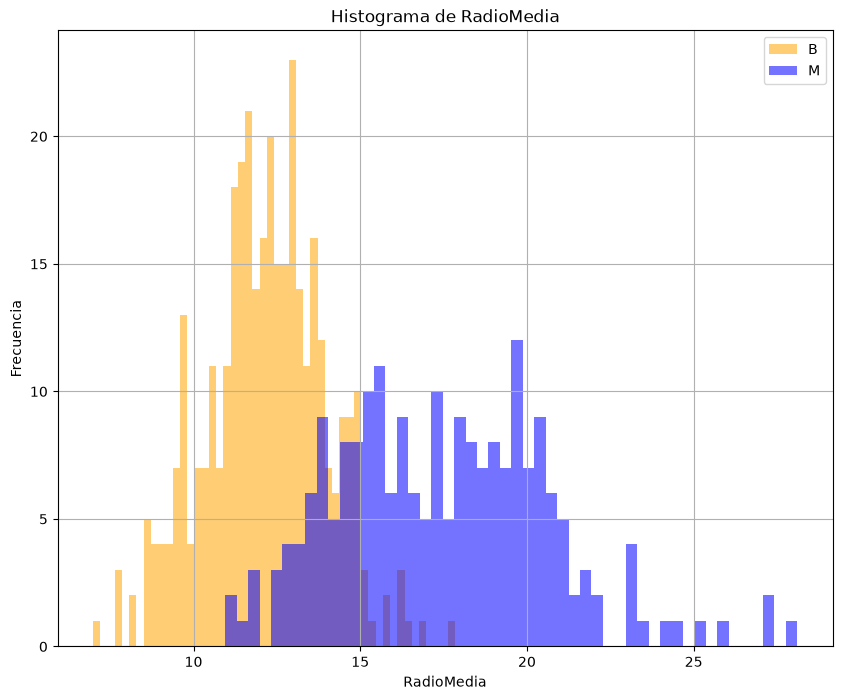

In [ ]:
plt.figure(figsize = (10 , 8))
plt.hist(dg[dg["Diagnostico"] == "B"]["RadioMedia"] , bins =50 , color = "orange",alpha = 0.55 , label = "B")
plt.hist(dg[dg["Diagnostico"] == "M"]["RadioMedia"] , bins =50 , color = "blue" , alpha = 0.55 ,label = "M")
plt.title("Histograma de RadioMedia")
plt.xlabel("RadioMedia")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid()
plt.show()

11.) Generar gráficos de violin para las columnas enunciandas, tenemos que.

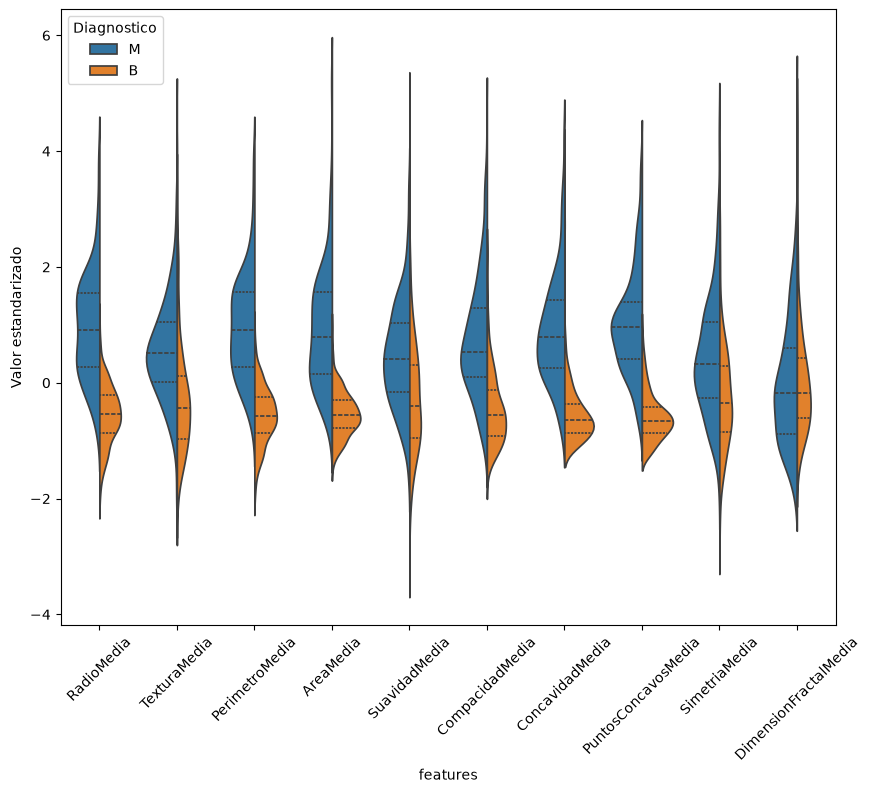

In [ ]:
plt.figure(figsize=(10,8))
from sklearn.preprocessing import StandardScaler

columnas = dg.columns[2:12]

dg_estandarizado = dg.copy()

scaler = StandardScaler()
dg_estandarizado[columnas] = scaler.fit_transform(dg[columnas])

data = pd.melt(
    dg_estandarizado,
    id_vars="Diagnostico",
    value_vars=columnas,
    var_name="features",
    value_name="value"
)

sns.violinplot(
    x="features",
    y="value",
    hue="Diagnostico",
    data=data,
    split=True,
    inner="quart"
)

plt.xticks(rotation=45)
plt.ylabel("Valor estandarizado")
plt.show()

12.) Para eliminar los valores atipicos en la columna RadioMedia utilizamos el puntaje Z.

In [ ]:
from scipy import stats
outliers = dg[(np.abs(stats.zscore(dg['RadioMedia'])) < 3)]
outliers

,ID,Diagnostico,RadioMedia,TexturaMedia,PerimetroMedia,AreaMedia,SuavidadMedia,CompacidadMedia,ConcavidadMedia,PuntosConcavosMedia,...,TexturaPeor,PerimetroPeor,AreaPeor,SuavidadPeor,CompacidadPeor,ConcavidadPeor,PuntosConcavosPeor,SimetriaPeor,DimensionFractalPeor,DiagnosticNumber
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,1
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,1
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,1
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,1
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,1
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,1
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,1
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,1


13). Determinado la matriz de correlacion, luego realizando el gráfico de esta matriz, por tanto.

In [ ]:
dg2 = dg.drop(columns = ["ID"])
variables_numericas = list(dg2.select_dtypes(include=np.number).columns)
matriz_correlacion = dg2[variables_numericas].corr()
matriz_correlacion

,RadioMedia,TexturaMedia,PerimetroMedia,AreaMedia,SuavidadMedia,CompacidadMedia,ConcavidadMedia,PuntosConcavosMedia,SimetriaMedia,DimensionFractalMedia,...,RadioPeor,TexturaPeor,PerimetroPeor,AreaPeor,SuavidadPeor,CompacidadPeor,ConcavidadPeor,PuntosConcavosPeor,SimetriaPeor,DimensionFractalPeor
RadioMedia,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
TexturaMedia,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
PerimetroMedia,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
AreaMedia,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
SuavidadMedia,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
CompacidadMedia,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
ConcavidadMedia,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
PuntosConcavosMedia,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
SimetriaMedia,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
DimensionFractalMedia,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.253691,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297


Heatmap de correlación.

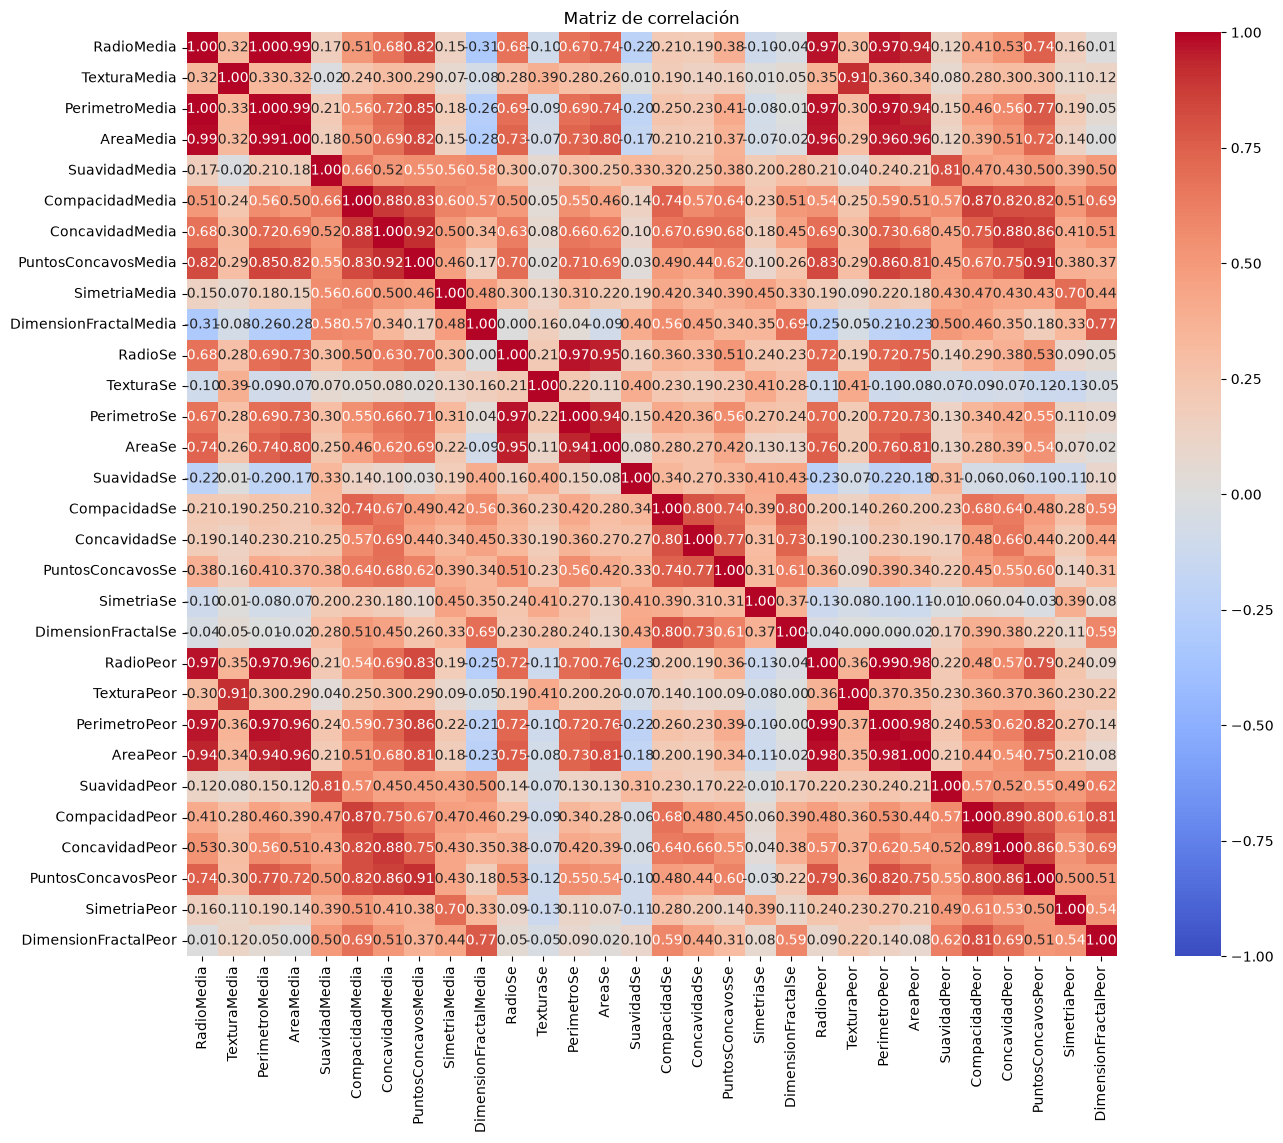

In [ ]:
plt.figure(figsize = (15 , 12))
sns.heatmap(matriz_correlacion, annot = True , cmap = "coolwarm", fmt = ".2f" , vmin = -1 , vmax = 1)
plt.title("Matriz de correlación")
plt.show()

14.) ¿Que otro tipo de gráficos pueden ser realizados para entender mejor los datos?
Rta//: Para analizar estos otros tipos de datos con graficas, serian mediante un histograma es 2D, boxplot, gráfico de barras.